In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report

In [2]:
print("\nLoading Dataset...") 
dataset = pd.read_csv("spam.csv", encoding="latin1") 
print("Dataset Loaded Successfully")


Loading Dataset...
Dataset Loaded Successfully


In [3]:
print("\nFirst Five Records") 
print(dataset.head()) 



First Five Records
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
print("\nDataset Information") 
dataset.info() 
print("\nDataset Shape") 
print(dataset.shape)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Dataset Shape
(5572, 2)


In [5]:
print("\nMissing Values") 
print(dataset.isnull().sum())


Missing Values
Category    0
Message     0
dtype: int64


In [6]:
print("\nEmail Category Count") 
print(dataset["Category"].value_counts())



Email Category Count
Category
ham     4825
spam     747
Name: count, dtype: int64


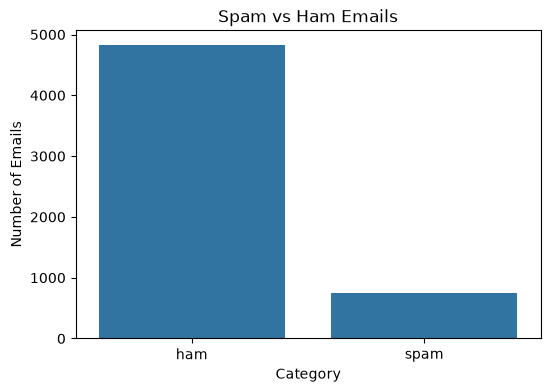

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Category",data=dataset)
plt.title("Spam vs Ham Emails")
plt.ylabel("Number of Emails")
plt.show()

In [8]:
x=dataset["Message"]
y=dataset["Category"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.20,
                                               random_state=42
                                              )
print("\n Training Samples:",len(x_train))
print("Testing Samples:",len(x_test))



 Training Samples: 4457
Testing Samples: 1115


In [10]:
print("\n Converting text into Numerical features...")
cv=CountVectorizer()
x_train=cv.fit_transform(x_train)
x_test=cv.transform(x_test)
print("Conversion Completed")
print("Training Data Shape:",x_train.shape)
print("Testing Data Shape:",x_test.shape)
    



 Converting text into Numerical features...
Conversion Completed
Training Data Shape: (4457, 7733)
Testing Data Shape: (1115, 7733)


In [11]:
print("\n Training SVM Model")
Classifier=SVC(kernel="linear")
Classifier.fit(x_train,y_train)
print("Model Training Completed")



 Training SVM Model
Model Training Completed


In [12]:
print("\n Predicting test data")
y_pred=Classifier.predict(x_test)
print("Prediction Completed")


 Predicting test data
Prediction Completed


In [13]:
accuracy = accuracy_score(y_test,y_pred) 
print("MODEL ACCURACY") 
print("Accuracy =",accuracy) 
print("Accuracy = {:.2f}%".format(accuracy*100))

MODEL ACCURACY
Accuracy = 0.989237668161435
Accuracy = 98.92%



Confusion Matrix
[[966   0]
 [ 12 137]]


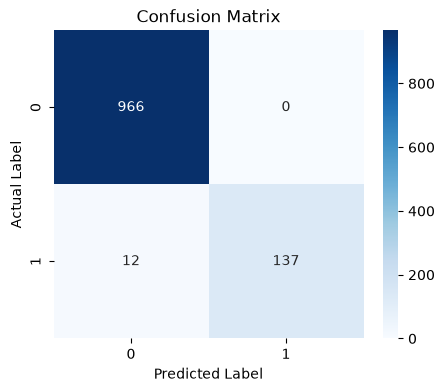

In [14]:
cm = confusion_matrix(y_test,y_pred) 
print("\nConfusion Matrix") 
print(cm) 
plt.figure(figsize=(5,4)) 
sns.heatmap(cm, 
annot=True, 
fmt='d', 
cmap='Blues') 
plt.xlabel("Predicted Label") 
plt.ylabel("Actual Label") 
plt.title("Confusion Matrix") 
plt.show()

In [15]:
print("\nClassification Report") 
print(classification_report(y_test,y_pred))


Classification Report
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.92      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [16]:
print("Sample Predictions") 
sample_messages = [ 
"Congratulations! You have won a free iPhone. Click here to claim.", 
"Hi, Shall we meet tomorrow at 10 AM?", 
"URGENT! Your bank account has been suspended. Verify immediately.", 
"Happy Birthday! Have a wonderful day.", 
"You have won Rs.50000 cash prize. Call now." 
] 
sample_data = cv.transform(sample_messages) 
predictions = Classifier.predict(sample_data) 
for message,prediction in zip(sample_messages,predictions): 
    print("\n Message :") 
    print(message) 
    print("Prediction :",prediction)

Sample Predictions

 Message :
Congratulations! You have won a free iPhone. Click here to claim.
Prediction : spam

 Message :
Hi, Shall we meet tomorrow at 10 AM?
Prediction : ham

 Message :
URGENT! Your bank account has been suspended. Verify immediately.
Prediction : spam

 Message :
Happy Birthday! Have a wonderful day.
Prediction : ham

 Message :
You have won Rs.50000 cash prize. Call now.
Prediction : spam
